In [7]:
import json, os
import pandas as pd
import numpy as np
import geopandas as gpd
import osmnx as ox
from matplotlib import pyplot as plt
import networkx as nx
from tqdm import tqdm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib

In [8]:
# import lts calculation functions
from lts_functions import (biking_permitted, is_separated_path, is_bike_lane, parking_present,
                           bike_lane_analysis_no_parking, bike_lane_analysis_with_parking, mixed_traffic)

# ## Extract OSM tags to use in download


f = open("victoriaosm.osm") # a larger bounding box for the city
data = json.load(f)

# +
# make a dataframe of tags
dfs = []

for element in data['elements']:
    if element['type'] != 'way':
        continue
    df = pd.DataFrame.from_dict(element['tags'], orient = 'index')
    dfs.append(df)
# -

tags_df = pd.concat(dfs).reset_index()
tags_df.columns = ["tag", "tagvalue"]

tag_value_counts = tags_df.value_counts().reset_index() # count all the unique tag and value combinations
tag_counts = tags_df['tag'].value_counts().reset_index() # count all the unique tags

print(tag_counts)

# explore the tags that start with 'cycleway'
tag_counts[tag_counts['tag'].str.contains('cycleway')]

way_tags = list(tag_counts['tag']) # all unique tags from the OSM Toronto download

# add the above list to the global osmnx settings
ox.settings.useful_tags_way += way_tags
ox.settings.osm_xml_way_tags = way_tags

                      tag  count
0                 highway  18306
1                 surface   8819
2                    name   6221
3                sidewalk   4609
4                maxspeed   3915
..                    ...    ...
253  payment:credit_cards      1
254   payment:debit_cards      1
255  parking:left:maxstay      1
256         class:bicycle      1
257             sac_scale      1

[258 rows x 2 columns]


In [9]:
# ### Download data

# create a filter to download selected data
# this filter is based on osmfilter = ox.downloader._get_osm_filter("bike")
# keeping the footway and construction tags
osmfilter = '["highway"]["area"!~"yes"]["access"!~"private"]["highway"!~"abandoned|bus_guideway|corridor|elevator|escalator|motor|planned|platform|proposed|raceway|steps"]["bicycle"!~"no"]["service"!~"private"]'

city = "Berkeley"
county= 'Alameda'
state = "California"

loading saved graph


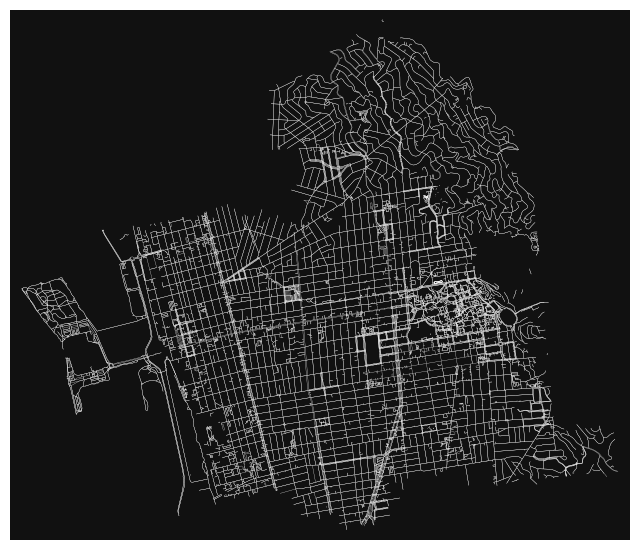

In [10]:
# check if data has already been downloaded; if not, download
filepath = "data/%s.graphml" %city
if os.path.exists(filepath):
    # load graph
    print("loading saved graph")
    G = ox.load_graphml(filepath)
else:
    # download data - this can be slow
    print("downloading data")
    G = ox.graph_from_place(
        "%s, %s, %s, USA" %(city, county, state),
        retain_all=True,
        truncate_by_edge=True,
        simplify=False,
        custom_filter=osmfilter,
    )
    # save graph
    print("saving graph")
    ox.save_graphml(G, filepath)

# plot downloaded graph - this is slow for a large area
fig, ax = ox.plot_graph(G, node_size=0, edge_color="w", edge_linewidth=0.2)
fig.savefig('data/plots/%s_fullnetwork.png'%city)

In [11]:
# ## Analyze LTS
#
# Start with is biking allowed, get edges where biking is not *not* allowed.

# convert graph to node and edge GeoPandas GeoDataFrames
gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)

print(gdf_edges.shape)
gdf_allowed, gdf_not_allowed = biking_permitted(gdf_edges)
print(gdf_allowed.shape)
print(gdf_not_allowed.shape)

# check for separated path
separated_edges, unseparated_edges = is_separated_path(gdf_allowed)
# assign separated ways lts = 1
separated_edges['lts'] = 1
print(separated_edges.shape)
print(unseparated_edges.shape)

to_analyze, no_lane = is_bike_lane(unseparated_edges)
print(to_analyze.shape)
print(no_lane.shape)

parking_detected, parking_not_detected = parking_present(to_analyze)
print(parking_detected.shape)
print(parking_not_detected.shape)

parking_lts = bike_lane_analysis_with_parking(parking_detected)

no_parking_lts = bike_lane_analysis_no_parking(parking_not_detected)

# Next, go to the last step - mixed traffic

lts_no_lane = mixed_traffic(no_lane)

# final components: lts_no_lane, parking_lts, no_parking_lts, separated_edges
# these should all add up to gdf_allowed
print(gdf_allowed.shape)
lts_no_lane.shape[0] + parking_lts.shape[0] + no_parking_lts.shape[0] + separated_edges.shape[0]

gdf_not_allowed['lts'] = 0

all_lts = pd.concat([separated_edges, parking_lts, no_parking_lts, lts_no_lane, gdf_not_allowed])

(79486, 118)
(70245, 119)
(9241, 119)
(19465, 120)
(50780, 118)
(1997, 118)
(48783, 118)
(0, 118)
(1997, 118)
(70245, 119)


In [12]:
# decision rule glossary
# these are from Bike Ottawa's stressmodel code
rule_message_dict = {'p2':'Cycling not permitted due to bicycle=\'no\' tag.',
                     'p6':'Cycling not permitted due to access=\'no\' tag.',
                     'p3':'Cycling not permitted due to highway=\'motorway\' tag.',
                     'p4':'Cycling not permitted due to highway=\'motorway_link\' tag.',
                     'p7':'Cycling not permitted due to highway=\'proposed\' tag.',
                     'p5':'Cycling not permitted. When footway="sidewalk" is present, there must be a bicycle="yes" when the highway is "footway" or "path".',
                     's3':'This way is a separated path because highway=\'cycleway\'.',
                     's1':'This way is a separated path because highway=\'path\'.',
                     's2':'This way is a separated path because highway=\'footway\' but it is not a crossing.',
                     's7':'This way is a separated path because cycleway* is defined as \'track\'.',
                     's8':'This way is a separated path because cycleway* is defined as \'opposite_track\'.',
                     'b1':'LTS is 1 because there is parking present, the maxspeed is less than or equal to 40, highway="residential", and there are 2 lanes or less.',
                     'b2':'Increasing LTS to 3 because there are 3 or more lanes and parking present.',
                     'b3':'Increasing LTS to 3 because the bike lane width is less than 4.1m and parking present.',
                     'b4':'Increasing LTS to 2 because the bike lane width is less than 4.25m and parking present.',
                     'b5':'Increasing LTS to 2 because the bike lane width is less than 4.5m, maxspeed is less than 40 on a residential street and parking present.',
                     'b6':'Increasing LTS to 2 because the maxspeed is between 41-50 km/h and parking present.',
                     'b7':'Increasing LTS to 3 because the maxspeed is between 51-54 km/h and parking present.',
                     'b8':'Increasing LTS to 4 because the maxspeed is over 55 km/h and parking present.',
                     'b9':'Increasing LTS to 3 because highway is not \'residential\'.',
                     'c1':'LTS is 1 because there is no parking, maxspeed is less than or equal to 50, highway=\'residential\', and there are 2 lanes or less.',
                     'c3':'Increasing LTS to 3 because there are 3 or more lanes and no parking.',
                     'c4':'Increasing LTS to 2 because the bike lane width is less than 1.7 metres and no parking.',
                     'c5':'Increasing LTS to 3 because the maxspeed is between 51-64 km/h and no parking.',
                     'c6':'Increasing LTS to 4 because the maxspeed is over 65 km/h and no parking.',
                     'c7':'Increasing LTS to 3 because highway with bike lane is not \'residential\' and no parking.',
                     'm17':'Setting LTS to 1 because motor_vehicle=\'no\'.',
                     'm13':'Setting LTS to 1 because highway=\'pedestrian\'.',
                     'm14':'Setting LTS to 2 because highway=\'footway\' and footway=\'crossing\'.',
                     'm2':'Setting LTS to 2 because highway=\'service\' and service=\'alley\'.',
                     'm15':'Setting LTS to 2 because highway=\'track\'.',
                     'm3':'Setting LTS to 2 because maxspeed is 50 km/h or less and service is \'parking_aisle\'.',
                     'm4':'Setting LTS to 2 because maxspeed is 50 km/h or less and service is \'driveway\'.',
                     'm16':'Setting LTS to 2 because maxspeed is less than 35 km/h and highway=\'service\'.',
                     'm5':'Setting LTS to 2 because maxspeed is up to 40 km/h, 3 or fewer lanes and highway=\'residential\'.',
                     'm6':'Setting LTS to 3 because maxspeed is up to 40 km/h and 3 or fewer lanes on non-residential highway.',
                     'm7':'Setting LTS to 3 because maxspeed is up to 40 km/h and 4 or 5 lanes.',
                     'm8':'Setting LTS to 4 because maxspeed is up to 40 km/h and the number of lanes is greater than 5.',
                     'm9':'Setting LTS to 2 because maxspeed is up to 50 km/h and lanes are 2 or less and highway=\'residential\'.',
                     'm10':'Setting LTS to 3 because maxspeed is up to 50 km/h and lanes are 3 or less on non-residential highway.',
                     'm11':'Setting LTS to 4 because the number of lanes is greater than 3.',
                     'm12':'Setting LTS to 4 because maxspeed is greater than 50 km/h.'}


In [13]:
simplified_message_dict = {'p2':r'bicycle $=$ "no"',
                     'p6':r'access $=$ "no"',
                     'p3':r'highway $=$ "motorway"',
                     'p4':r'highway $=$ "motorway_link"',
                     'p7':r'highway $=$ "proposed"',
                     'p5':r'footway $=$ "sidewalk", bicycle$\neq$"yes"',
                     's3':r'highway $=$ "cycleway"',
                     's1':r'highway $=$" path"',
                     's2':r'separated, highway $=$" footway", not a crossing',
                     's7':r'cycleway* $=$ "track"',
                     's8':r'cycleway* $=$ "opposite_track"',
                     'b1':r'bike lane w/ parking, $\leq$ 40 km/h, highway $=$ "residential", $\leq$ 2 lanes',
                     'b2':r'bike lane w/ parking, 3 or more lanes',
                     'b3':r'bike lane width $<$ 4.1m, parking',
                     'b4':r'bike lane width $<$ 4.25m, parking',
                     'b5':r'bike lane width $<$ 4.5m, $\leq$ 40 km/h, residential, parking',
                     'b6':r'bike lane w/ parking, speed 41-50 km/h',
                     'b7':r'bike lane w/ parking, speed 51-54 km/h',
                     'b8':r'bike lane w/ parking, speed $>$ 55 km/h',
                     'b9':r'bike lane w/ parking, highway $\neq$ "residential"',
                     'c1':r'bike lane no parking, $\leq$ 50 km/h, highway $=$ "residential", $\leq$ 2 lanes',
                     'c3':r'bike lane no parking, $\leq$ 65 km/h, $\geq$ 3 lanes',
                     'c4':r'bike lane width $<$ 1.7m, no parking',
                     'c5':r'bike lane no parking, speed 51-64 km/h',
                     'c6':r'bike lane no parking, speed $>$ 65 km/h',
                     'c7':r'bike lane no parking, highway $\neq$ "residential"',
                     'm17':r'mixed traffic, motor_vehicle $=$ "no"',
                     'm13':r'mixed traffic, highway $=$ "pedestrian"',
                     'm14':r'mixed traffic, highway $=$ "footway", footway $=$ "crossing"',
                     'm2':r'mixed traffic, highway $=$ "service", service $=$ "alley"',
                     'm15':r'mixed traffic, highway $=$ "track"',
                     'm3':r'mixed traffic, speed $\leq$ 50 km/h, service $=$ "parking_aisle"',
                     'm4':r'mixed traffic, speed $\leq$ 50 km/h, service $=$ "driveway"',
                     'm16':r'mixed traffic, speed $\leq$ 35 km/h, highway $=$ "service"',
                     'm5':r'mixed traffic, speed $\leq$ 40 km/h, highway $=$ "residential", $\leq$ 3 lanes',
                     'm6':r'mixed traffic, speed $\leq$ 40 km/h, highway $\neq$ "residential", $\leq$ 3 lanes',
                     'm7':r'mixed traffic, speed $\leq$ 40 km/h, 4 or 5 lanes',
                     'm8':r'mixed traffic, speed $\leq$ 40 km/h, lanes $>$ 5',
                     'm9':r'mixed traffic, speed $\leq$ 50 km/h, highway $=$ "residential",$\leq$ 2 lanes',
                     'm10':r'mixed traffic, speed $\leq$ 50 km/h, highway $\neq$ "residential", $\leq$ 3 lanes',
                     'm11':r'mixed traffic, speed $\leq$ 50 km/h, lanes $>$ 3',
                     'm12':r'mixed traffic, speed $>$ 50 km/h'}

all_lts['message'] = all_lts['rule'].map(rule_message_dict)
all_lts['short_message'] = all_lts['rule'].map(simplified_message_dict)


In [14]:
# ## Node LTS
#
# Calculate node LTS.
#
# - An intersection without either was assigned the highest LTS of its intersecting roads.
# - Stop signs reduced an otherwise LTS2 intersection to LTS1.
# - A signalized intersection of two lowstress links was assigned LTS1.
# - Assigned LTS2 to signalized intersections where a low-stress (LTS1/ 2) link crosses a high-stress (LTS3/4) link.

gdf_nodes['highway'].value_counts()

# +
gdf_nodes['lts'] = np.nan # make lts column
gdf_nodes['message'] = '' # make message column

for node in tqdm(gdf_nodes.index):
    try:
        edges = all_lts.loc[node]
    except:
        #print("Node not found in edges: %s" %node)
        gdf_nodes.loc[node, 'message'] = "Node not found in edges"
        continue
    control = gdf_nodes.loc[node,'highway'] # if there is a traffic control
    max_lts = edges['lts'].max()
    node_lts = int(max_lts) # set to max of intersecting roads
    message = "Node LTS is max intersecting LTS"
    if node_lts > 2:
        if control == 'traffic_signals':
            node_lts = 2
            message = "LTS 3-4 with traffic signals"
    elif node_lts <= 2:
        if control == 'traffic_signals' or control == 'stop':
            node_lts = 1
            message = "LTS 1-2 with traffic signals or stop"

    gdf_nodes.loc[node,'message'] = message
    gdf_nodes.loc[node,'lts'] = node_lts # assign node lts
# -


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 38202/38202 [02:24<00:00, 264.69it/s]


In [15]:
# ### Save data for plotting

gdf_nodes.to_csv("data/gdf_nodes_%s.csv" %city)

all_lts_small = all_lts[['osmid', 'lanes', 'name', 'highway', 'maxspeed', 'geometry', 'length', 'rule', 'lts',
                         'lanes_assumed', 'maxspeed_assumed', 'message', 'short_message']]
all_lts_small.to_csv("data/all_lts_%s.csv" %city)

# make graph with LTS information
#G_lts = ox.graph_from_gdfs(gdf_nodes, all_lts_small)
G_lts = ox.graph_from_gdfs(gdf_nodes[(gdf_nodes['lts']!=0)], all_lts_small[(all_lts_small['lts']!=0)]) #don't include "LTS = 0" --> bicycles not allowed

# save LTS graph
filepath = "data/%s_lts.graphml" %city
ox.save_graphml(G_lts, filepath)



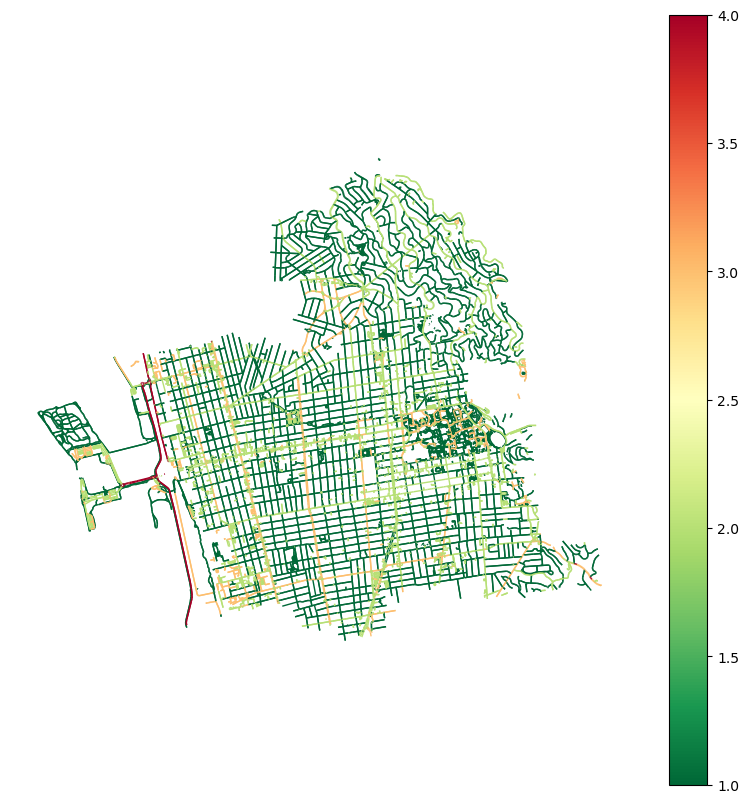

In [16]:
## All ways LTS
fig1, ax1 = plt.subplots(figsize=(10,10))

all_lts_small[(all_lts_small['lts']<=4) & (all_lts_small['lts']!=0)].plot(
    ax=ax1,
    column="lts",
    linewidth=1,
    cmap='RdYlGn_r',
    legend=True)

ax1.axis("off")
plt.show()
fig1.savefig('data/plots/%s_lts_ways.png'%city)

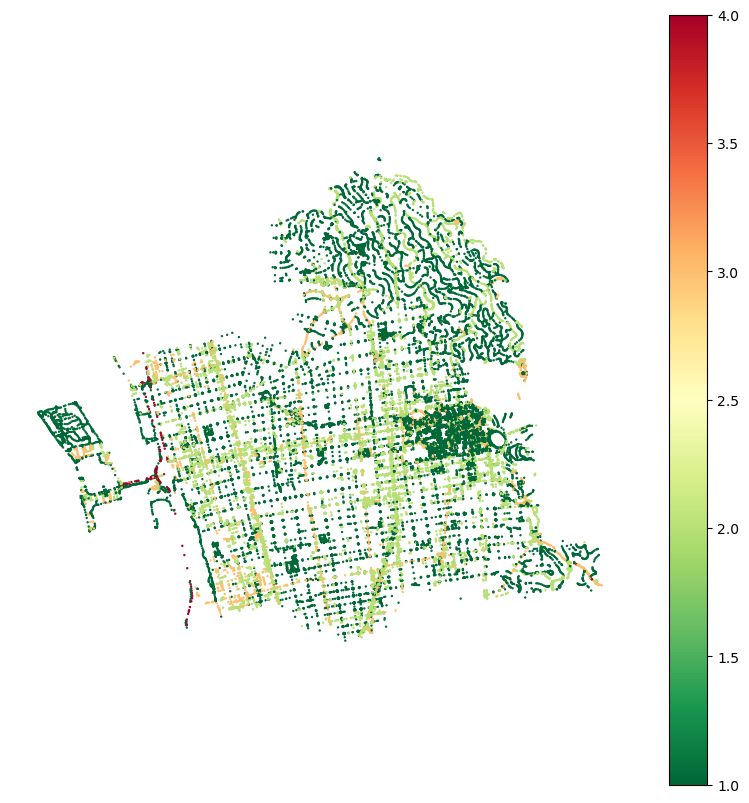

In [17]:
## All nodes LTS

fig2, ax2 = plt.subplots(figsize=(10,10))

gdf_nodes[(gdf_nodes['lts']<=4) & (gdf_nodes['lts']!=0)].plot(
    ax=ax2,
    column="lts",
    markersize=0.5,
    linewidth=1,
    cmap='RdYlGn_r',
    legend=True)

ax2.axis("off")
plt.show()
fig2.savefig('data/plots/%s_lts_nodes.png'%city)

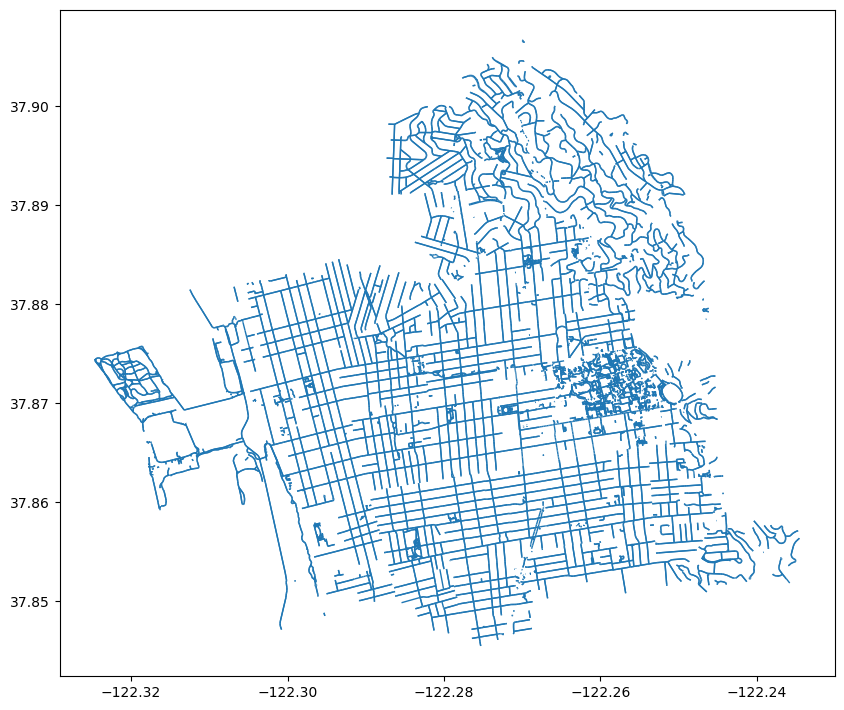

In [18]:
## filtered LTS <=2
fig3, ax3 = plt.subplots(figsize=(10,10))

all_lts_small[(all_lts_small['lts']<=1) & (all_lts_small['lts']!=0)].plot(
    ax=ax3,
    #column="lts",
    linewidth=1,
    #cmap='YlGn_r',
    legend=True)

ax1.axis("off")
plt.show()


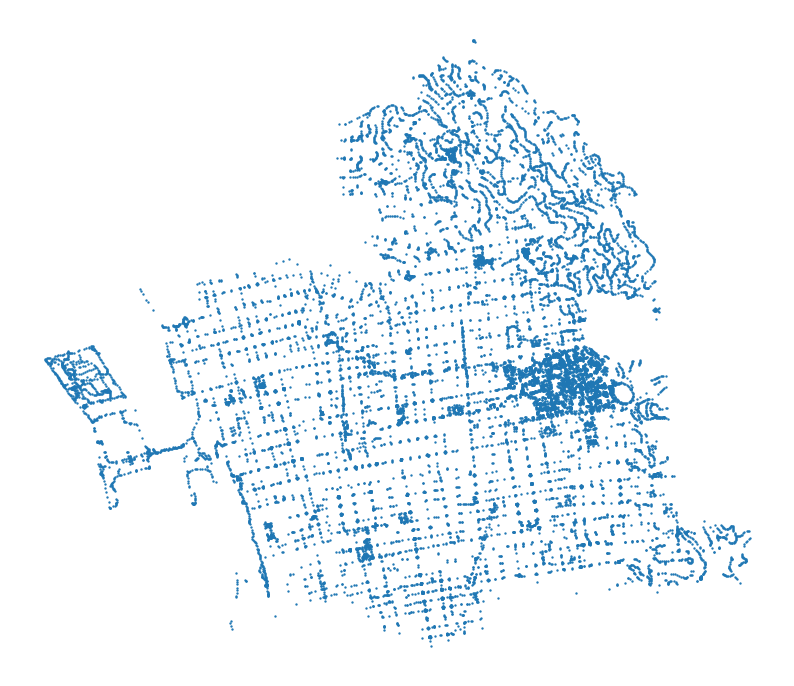

In [19]:
## Filtered LTS <=2
fig4, ax4 = plt.subplots(figsize=(10,10))

gdf_nodes[(gdf_nodes['lts']<=1) & (gdf_nodes['lts']!=0)].plot(
    ax=ax4,
    #column="lts",
    markersize=0.5,
    linewidth=1,
    #cmap=cmap,
    legend=True)

ax4.axis("off")
plt.show()

In [20]:
#fig, ax = ox.plot_graph(G_lts, node_color='r', edge_linewidth=0.3)

In [21]:
## Filtered network: remove nodes/ways first, then convert gdfs to graph
G_low_stress=ox.graph_from_gdfs(gdf_nodes[(gdf_nodes['lts']<=2) & (gdf_nodes['lts']!=0)]
                   ,all_lts_small[(all_lts_small['lts']<=2) & (all_lts_small['lts']!=0)])

In [22]:
## Filtered network graph with only low-stress ways/nodes - remove all ways/nodes with LTS above 2
#G_low_stress = G_lts.copy().to_undirected()
#G_low_stress.remove_nodes_from(gdf_nodes[(gdf_nodes['lts']>2)])
#G_low_stress.remove_edges_from(all_lts_small[all_lts_small['lts']>2])



# save LTS graph
#filepath = "data/%s_low_stress.graphml" %city
#ox.save_graphml(G_lts, filepath)

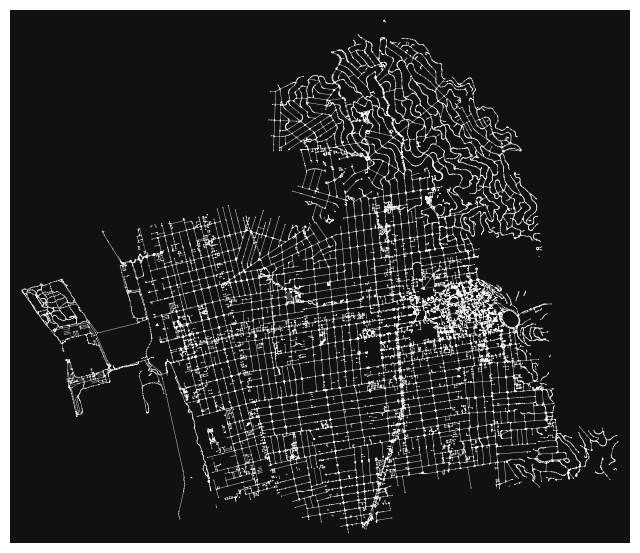

In [23]:
fig5, ax5 = ox.plot_graph(G_low_stress, node_size=0.5, edge_linewidth=0.3)
fig5.savefig('data/plots/%s_low_stress.png'%city)

In [24]:
#Compare to original:
#fig, ax = ox.plot_graph(G_lts, node_size=0.5, edge_linewidth=0.3)
## Not able to plot G_lts or convert it back to gdfs for some reason ....
## so note that this still incldes sidewalks and other LTS=0 places where biking is not permitted
## Actually, instead make a new graph where LTS=0 is filtered out
#G_all_biking=ox.graph_from_gdfs(gdf_nodes[(gdf_nodes['lts']!=0)]
#                   ,all_lts_small[(all_lts_small['lts']!=0)])

#G_all_biking=ox.graph_from_gdfs(gdf_nodes[(gdf_nodes['lts']<=2) & (gdf_nodes['lts']!=0)]
#                   ,all_lts_small[(all_lts_small['lts']<=2) & (all_lts_small['lts']!=0)])
#fig6, ax6 = ox.plot_graph(G_all_biking, node_size=0.5, edge_linewidth=0.3)
#fig6.savefig('data/plots/%s_all_biking.png'%city)

In [25]:
#nodes_gdf_low_stress, edges_gdf_low_stress = ox.graph_to_gdfs(G_low_stress)

### PART 2: Connectivity metrics by census tract

In [26]:
## find largest connected components

#largest_cc = max(nx.connected_components(G_low_stress.to_undirected()), key=len)
#G_lcc = G_low_stress.subgraph(largest_cc).copy()

In [27]:
#nodes_lcc,edges_lcc = ox.graph_to_gdfs(G_lcc)

#fig, ax = plt.subplots(figsize=(10,10))

#all_lts_small.plot(ax=ax, color="black", linewidth=0.6, zorder=1)
#ax.axis("off")

### ok in general converting back from graph to gdfs is not working, no idea why since all node and edge data seems to be fine .... 

#### Get Census Tracts

In [28]:
## import census tracts

import pycen
from pycen import explore, acquire
import pandas as pd

pycen_place = "%s city"%city
pycen_state = "CA"
dataset = "acs5"
year = 2019  # keep consistent across pycen calls

# Output 
#out_gpkg = "sanjose_voronoi_population_pycen.gpkg"

### Quick visualization of ridership per census tract

#tracts = acquire.get_censhp(
#    variables=['B08301_018E',"B01003_001E"],
#    geography="tract",
#    place=pycen_place,
#    state=pycen_state,
#    dataset=dataset,
#    year=year
#).rename(columns={'B08301_018E': "total_bike","B01003_001E":"total_pop"})

#tracts["total_bike"] = pd.to_numeric(tracts["total_bike"], errors="coerce").fillna(0)
#tracts['pct_bike']=tracts['total_bike']/tracts["total_pop"] *100

# Quick look
#tracts[["total_bike", "geometry"]].head()

## quick visualization
#acquire.quick_viz(tracts, "pct_bike")


In [29]:
## create boundaries for all census tracts in a city
## From assignment 2 voronoi code
bg = acquire.get_censhp(
    variables=["B19001_001E"],   # any variable is fine; we only need geometry
    geography="tract",
    place=pycen_place,
    state=pycen_state,
    dataset=dataset,
    year=year
)

boundary = bg.geometry
boundary

Resolving geography...
  State: California (CA, FIPS: 06)
Loading from cache: pycen_cache/api/acs5_2019_tract_06__d4a903a509b729a9.csv
Loading boundaries from cache...
Merging data...
Clipping to place: Berkeley city
Fetching boundaries...


323     MULTIPOLYGON (((-122.27375 37.87779, -122.2691...
491     MULTIPOLYGON (((-122.30085 37.87757, -122.2953...
514     MULTIPOLYGON (((-122.25459 37.86932, -122.2523...
582     MULTIPOLYGON (((-122.29223 37.86904, -122.2880...
583     MULTIPOLYGON (((-122.28965 37.8611, -122.28123...
1407    MULTIPOLYGON (((-122.26452 37.86068, -122.2535...
1572    MULTIPOLYGON (((-122.28327 37.88093, -122.2826...
1717    MULTIPOLYGON (((-122.28204 37.87035, -122.2730...
1883    MULTIPOLYGON (((-122.29775 37.86794, -122.2922...
1987    MULTIPOLYGON (((-122.27119 37.8997, -122.26959...
2050    MULTIPOLYGON (((-122.27307 37.87151, -122.2684...
2308    MULTIPOLYGON (((-122.26633 37.87419, -122.2653...
2310    MULTIPOLYGON (((-122.26241 37.85586, -122.2568...
2583    MULTIPOLYGON (((-122.26575 37.87881, -122.2580...
2607    MULTIPOLYGON (((-122.28123 37.8622, -122.27657...
2935    MULTIPOLYGON (((-122.26599 37.86783, -122.2614...
3642    MULTIPOLYGON (((-122.26774 37.89313, -122.2626...
3645    MULTIP

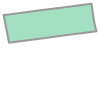

In [30]:
boundary_i=boundary.iloc[15]
boundary_i
## just choosing an arbitrary census tract for right now to experiment with

In [31]:
## Select nodes and edges located within census tract boundary


## NOTE/TODO for others working on this
## still have to change this to only be using the low-stress network
## (eg. filter gdf_nodes to only the low stress nodes and all_lts_small to only the low stress edges for the code below)
## also need to filter out LTS=0
## also need to eventually iterate/apply across all census tracts in the city
## But for now you can just try doing connectivity analysis on individual census tracts?
## then we can just run whatever analysis you come up with across all census tracts

nodes_in = gdf_nodes[gdf_nodes.geometry.within(boundary_i)].copy().reset_index(drop=False)
edges_in = all_lts_small[all_lts_small.geometry.within(boundary_i)].copy().reset_index(drop=False)

G_in = ox.graph_from_gdfs(nodes_in,all_lts_small)

<Axes: >

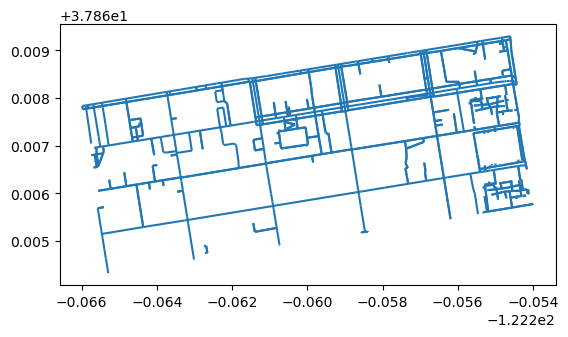

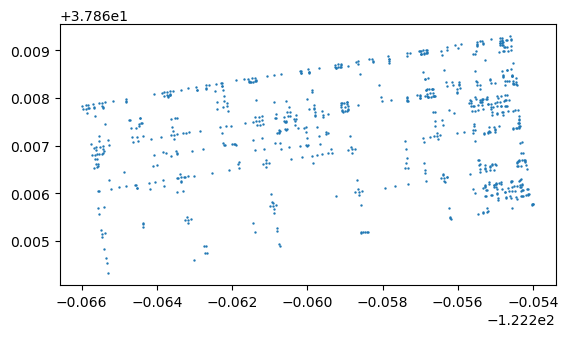

In [52]:
edges_in.plot()
nodes_in.plot(markersize=0.5)

In [53]:
bg.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

In [50]:
nodes_by_tract = gpd.sjoin(
    gdf_nodes.to_crs(bg.crs),
    bg[["geometry"]],
    how="inner",
    predicate="within"
)

edges_by_tract = gpd.sjoin(
    all_lts_small.to_crs(bg.crs),
    bg[["geometry"]],
    how="inner",
    predicate="within"
)

In [61]:
bg['nodes'] = nodes_by_tract.groupby('index_right')['index_right'].count()

In [63]:
bg['edges'] = edges_by_tract.groupby('index_right')['index_right'].count()

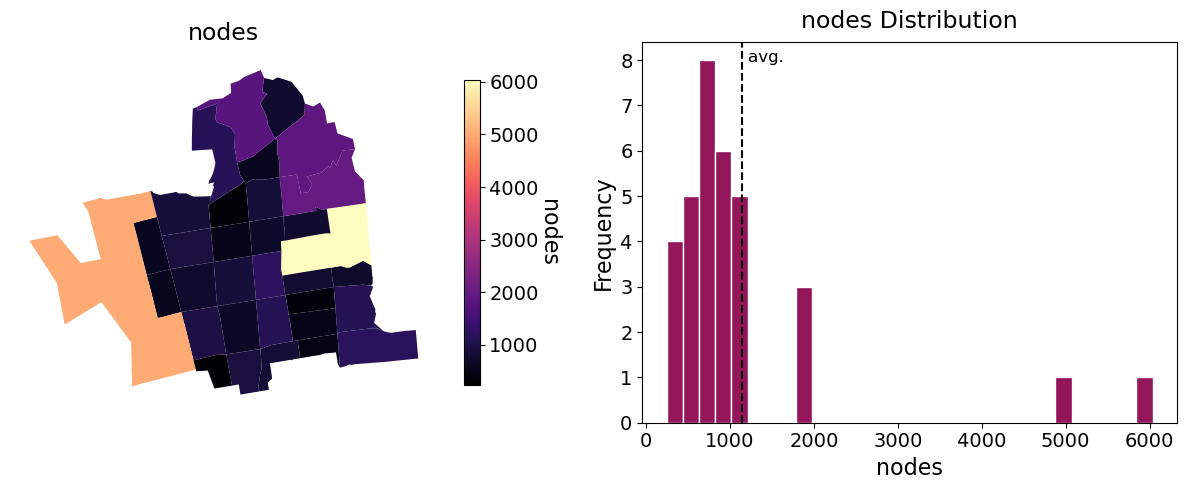

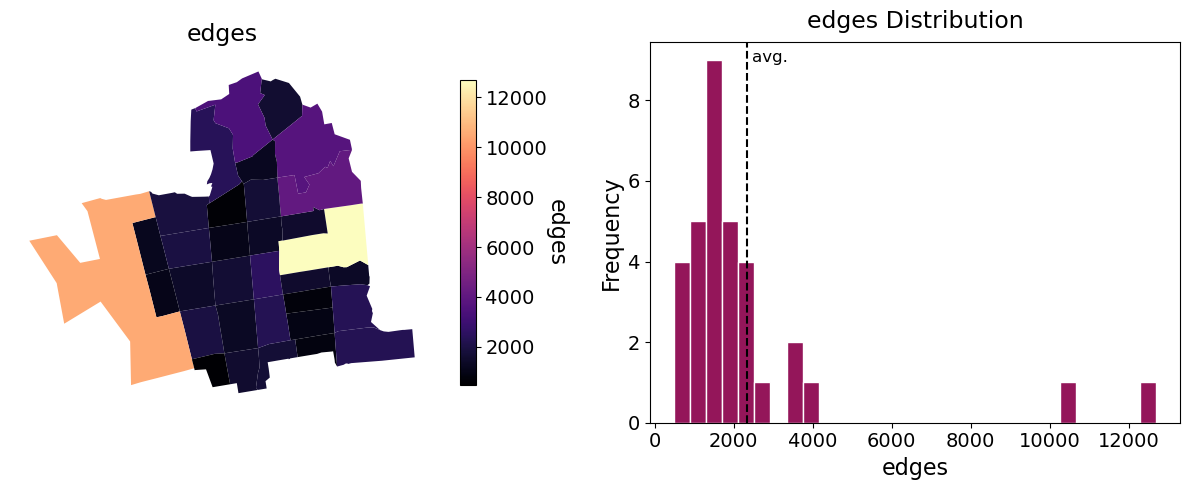

In [67]:
acquire.quick_viz(bg, "nodes")
acquire.quick_viz(bg, "edges")